In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# フィッティング: 基本

**目的**: 通常最小二乗法（OLS）および一般化最小二乗法（GLS）を使用して GW データにモデルをフィットする方法を学びます。

GWexpy は主要な最適化エンジンとして **iminuit** を使用し、相関を持つスペクトルデータ用の特化したコスト関数を提供します。

## 1. 単純な OLS フィット

対角誤差（OLS）を使った単純なべき乗則フィットから始めます。

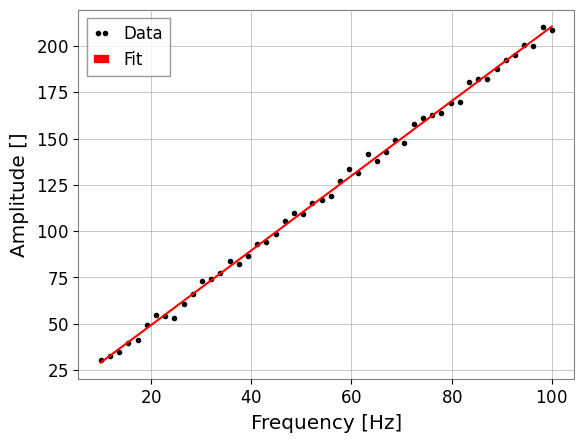

Fitted a=2.01, b=8.94


In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np

from gwexpy.fitting import fit_series

# Generate synthetic data
freqs = np.linspace(10, 100, 50)
model = lambda f, a, b: a * f + b
y_true = model(freqs, 2.0, 10.0)
y_obs = y_true + np.random.normal(0, 2, size=len(freqs))

from gwexpy.frequencyseries import FrequencySeries

psd = FrequencySeries(y_obs, frequencies=freqs)

res = fit_series(psd, model, p0={"a": 1.0, "b": 1.0})

res.plot()
plt.show()
print(f"Fitted a={res.params['a']:.2f}, b={res.params['b']:.2f}")

## 2. 一般化最小二乗法（GLS）

データ点が相関している場合（例：重なり窓を使った PSD 推定）、共分散行列 $\Sigma$ を使用します。

In [3]:
from iminuit import Minuit

from gwexpy.fitting import GeneralizedLeastSquares

# Create a dummy covariance matrix
cov = np.eye(len(freqs)) * 4.0
cov_inv = np.linalg.inv(cov)

# 1. Define Cost Function
cost = GeneralizedLeastSquares(freqs, y_obs, cov_inv, model, cov=cov)

# 2. Initialize and Run Minuit
m = Minuit(cost, a=1.0, b=1.0)
m.migrad()

print(m.values)

<ValueView a=2.014993017455686 b=8.935244478263794>


## 3. 高レベル統合パイプライン

実際の解析では、ブートストラップ法を使ってデータ自体から共分散行列を推定することが多いです。GWexpy はこのための統合パイプラインを提供しています。

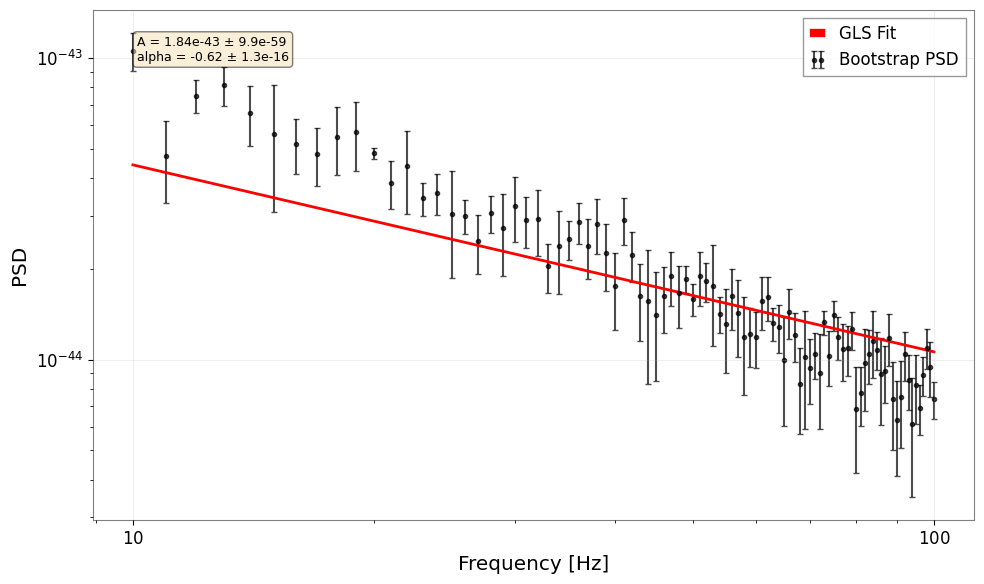

In [4]:
from gwexpy.fitting.highlevel import fit_bootstrap_spectrum
from gwexpy.noise.wave import colored

# Generate 10 seconds of pink noise
data = colored(duration=10, sample_rate=256, exponent=0.5, amplitude=1e-21)

def power_law(f, A, alpha):
    return A * f**alpha

result = fit_bootstrap_spectrum(
    data,
    model_fn=power_law,
    freq_range=(10, 100),
    fftlength=1.0,
    overlap=0.5,
    initial_params={"A": 1e-21, "alpha": -0.5},
    plot=True
)

## 4. 演習

1. **パラメータ制約**: `fit_series` の `limits` 引数を使って `a > 0` となるよう OLS フィットを修正してください。
2. **MCMC**: セクション 3 で `run_mcmc=True` を設定して MCMC を有効にしてください（`emcee` が必要）。

## 5. 検証セル（NBMAKE）

In [5]:
assert "a" in res.params
assert result.reduced_chi2 > 0
print("Validation successful!")

Validation successful!
